In [104]:
from tensorflow.keras.models import load_model
modelt = load_model('D:\ds\dl\cnn\license_plate\model_checkpoint2.keras')
modelt.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 17, 20, 2048)   │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 140)            │       286,860 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 140)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           564 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,381,314 (127.34 MB)

 Trainable params: 4,753,088 (18.13 MB)

 Non-trainable params: 19,122,048 (72.94 MB)

 Optimizer params: 9,506,178 (36.26 MB)

In [105]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [106]:
avgw, avgh = (610, 513)
#avgw, avgh = (512, 512)

In [172]:
i  = "D:\\ds\\dl\\cnn\\license_plate\\data\\license_plates_detection_train\\55.jpg"
img= Image.open(i)
size = img.size
img = img.resize((avgw,avgh))
print(os.path.basename(i))
print("from ",size," to ",img.size)
img = img.convert('RGB')
img_array = np.array(img)

55.jpg
from  (850, 477)  to  (610, 513)


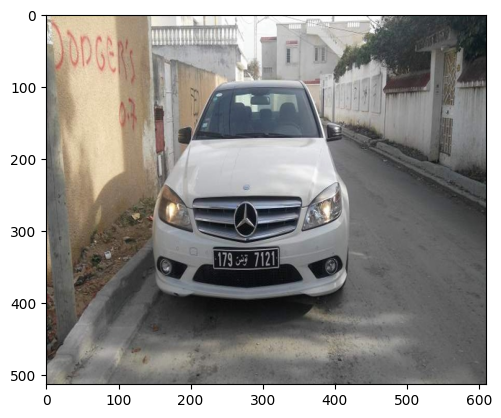

In [173]:
plt.imshow(img_array)

In [174]:
img_array1 = img_array.reshape(1,513,610,3)
img_array1.shape

(1, 513, 610, 3)

In [175]:
img_array1 = img_array1/255.0

In [176]:
bound = modelt.predict(img_array1)
bound

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


array([[0.3771919 , 0.6077515 , 0.59256303, 0.7230998 ]], dtype=float32)

In [177]:
bound = bound[0]
bound[0]=bound[0]*avgw
bound[1]=bound[1]*avgh
bound[2]=bound[2]*avgw
bound[3]=bound[3]*avgh

In [178]:
print(bound)

[230.08707 311.77652 361.46344 370.95023]


In [179]:
bound = [int(round(bound[i])) for i in range(0,4)]
bound

[230, 312, 361, 371]

(-0.5, 609.5, 512.5, -0.5)

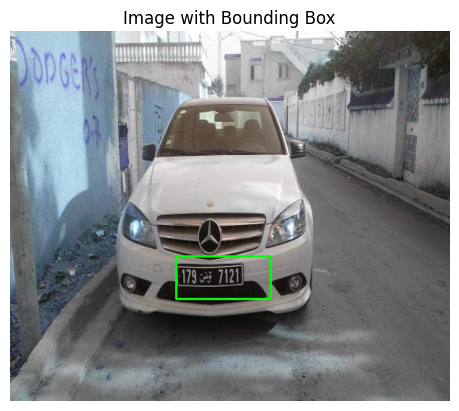

In [180]:
import cv2
import matplotlib.pyplot as plt

image =   img_array

bound = bound
xmin, ymin, xmax, ymax = bound[0],bound[1],bound[2],bound[3]

# Step 3: Draw the bounding box
cv2.rectangle(image, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)  # Green color, thickness 2

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # Display the image using matplotlib
plt.imshow(image_rgb) 
plt.title('Image with Bounding Box') 
plt.axis('off') # Hide axis

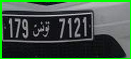

In [181]:
from PIL import Image
image = Image.fromarray(image)
box = (bound[0],bound[1],bound[2],bound[3])
cropped_image = image.crop(box)
cropped_image

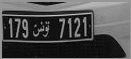

In [182]:
grayscale_image = cropped_image.convert("L")
grayscale_image

In [183]:
import pytesseract
pytesseract.pytesseract.tesseract_cmd = r'C:\\Program Files\\Tesseract-OCR\\tesseract.exe'

In [184]:
plate = pytesseract.image_to_string(grayscale_image, lang='eng')
print("Number plate is:", plate)

Number plate is: 19.3 7121

